In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Importar as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging
import sys

logging.basicConfig(
    level=logging.ERROR,
    format='%(levelname)s - %(message)s',
    force=True,
    handlers=[logging.StreamHandler(sys.stdout)]
)

In [3]:
# Configurar o estilo dos gráficos
sns.set_theme(style="whitegrid")

# Ler os dados (ignorando o cabeçalho do INMET)
df_2022 = pd.read_csv("dataset/clima/NITEROI 2022.CSV", sep=";", skiprows=8, encoding="latin1")
df_2023 = pd.read_csv("dataset/clima/NITEROI 2023.CSV", sep=";", skiprows=8, encoding="latin1")
df_2024 = pd.read_csv("dataset/clima/NITEROI 2024.CSV", sep=";", skiprows=8, encoding="latin1")
df_2025 = pd.read_csv("dataset/clima/NITEROI 2025.CSV", sep=";", skiprows=8, encoding="latin1")

# Unir os dados num único DataFrame
df = pd.concat([df_2022, df_2023, df_2024, df_2025], ignore_index=True)

# Remover a coluna vazia gerada pelo ponto e vírgula no final das linhas
if 'Unnamed: 19' in df.columns:
    df = df.drop(columns=['Unnamed: 19'])

In [4]:
# Renomear as colunas para nomes mais curtos e padronizados
novos_nomes = {
    'Data': 'DATA',
    'Hora UTC': 'HORA_UTC',

    'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)': 'PRECIPITACAO_MM',

    'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)': 'PRESSAO_ESTACAO_MB',
    'PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)': 'PRESSAO_ESTACAO_MAX_H_ANT_MB',
    'PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)': 'PRESSAO_ESTACAO_MIN_H_ANT_MB',

    'RADIACAO GLOBAL (Kj/m²)': 'RADIACAO_GLOBAL_KJ_M2',

    'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)': 'TEMP_AR_C',
    'TEMPERATURA DO PONTO DE ORVALHO (°C)': 'TEMP_ORVALHO_C',

    'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)': 'TEMP_MAX_H_ANT_C',
    'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)': 'TEMP_MIN_H_ANT_C',

    'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)': 'TEMP_ORVALHO_MAX_H_ANT_C',
    'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)': 'TEMP_ORVALHO_MIN_H_ANT_C',

    'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)': 'UMIDADE_REL_MAX_H_ANT_PCT',
    'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)': 'UMIDADE_REL_MIN_H_ANT_PCT',
    'UMIDADE RELATIVA DO AR, HORARIA (%)': 'UMIDADE_REL_HORARIA_PCT',

    'VENTO, DIREÇÃO HORARIA (gr) (° (gr))': 'VENTO_DIRECAO_GRAUS',
    'VENTO, RAJADA MAXIMA (m/s)': 'VENTO_RAJADA_MAX_MS',
    'VENTO, VELOCIDADE HORARIA (m/s)': 'VENTO_VELOCIDADE_MS',
}

# Aplicando a renomeação no DataFrame
df = df.rename(columns=novos_nomes)

In [5]:
# Conferindo o resultado
df.head()
#print(df.columns.tolist())

,DATA,HORA_UTC,PRECIPITACAO_MM,PRESSAO_ESTACAO_MB,PRESSAO_ESTACAO_MAX_H_ANT_MB,PRESSAO_ESTACAO_MIN_H_ANT_MB,RADIACAO_GLOBAL_KJ_M2,TEMP_AR_C,TEMP_ORVALHO_C,TEMP_MAX_H_ANT_C,TEMP_MIN_H_ANT_C,TEMP_ORVALHO_MAX_H_ANT_C,TEMP_ORVALHO_MIN_H_ANT_C,UMIDADE_REL_MAX_H_ANT_PCT,UMIDADE_REL_MIN_H_ANT_PCT,UMIDADE_REL_HORARIA_PCT,VENTO_DIRECAO_GRAUS,VENTO_RAJADA_MAX_MS,VENTO_VELOCIDADE_MS
0,2022/01/01,0000 UTC,0,"1008,8","1008,8","1008,2",NaN,"24,7","22,6",25,"24,7","22,8","22,4",89.0,86.0,88.0,66.0,"4,6","1,4"
1,2022/01/01,0100 UTC,",2",1009,"1009,1","1008,7",NaN,"24,6","22,3",25,"24,6","22,7","22,1",89.0,84.0,87.0,74.0,"5,2",",7"
2,2022/01/01,0200 UTC,",4","1009,3","1009,6",1009,NaN,"23,4","23,3","24,7","23,3","23,3","22,1",100.0,86.0,100.0,39.0,"2,1",",3"
3,2022/01/01,0300 UTC,",2","1007,9","1009,4","1007,9",NaN,24,"21,1","24,2","23,1","23,3","21,1",100.0,83.0,84.0,75.0,"6,2","2,4"
4,2022/01/01,0400 UTC,0,"1007,5","1007,9","1007,5",NaN,"23,9","20,5",24,"22,9","21,9","20,2",94.0,79.0,81.0,53.0,"6,2","1,3"


In [6]:
# Verificamos se as colunas ainda existem no DataFrame
if 'DATA' in df.columns and 'HORA_UTC' in df.columns:

    try:
        # Pega a posição da coluna DATA
        idx_data = df.columns.get_loc('DATA')

        # Converte a data e extrai o mês
        mes_series = pd.to_datetime(df['DATA']).dt.month

        # Insere MES na mesma posição da DATA
        df.insert(idx_data, 'MES', mes_series)

    except Exception as e:
        logging.error(f"Erro ao converter a coluna DATA: {e}")

    try:
        # Pega a posição da coluna HORA_UTC
        idx_hora = df.columns.get_loc('HORA_UTC')

        # Extrai apenas a hora
        hora_series = (
            df['HORA_UTC']
            .astype(str)
            .str.replace(' UTC', '', regex=False)
            .astype(int) // 100
        )

        # Insere HORA na mesma posição da HORA_UTC
        df.insert(idx_hora, 'HORA', hora_series)

    except Exception as e:
        logging.error(f"Erro ao extrair a coluna HORA: {e}")

    # Remove colunas originais
    df = df.drop(columns=['DATA', 'HORA_UTC'])

    print("Sucesso: colunas de tempo processadas e substituídas.")

else:
    print("As colunas DATA e HORA_UTC já foram processadas anteriormente.")

Sucesso: colunas de tempo processadas e substituídas.


In [7]:
# Trata colunas numéricas que vieram como texto

# Seleciona apenas colunas textuais
colunas_texto = df.select_dtypes(include=['object', 'string']).columns

for col in colunas_texto:

    # Troca vírgula decimal por ponto
    df[col] = df[col].astype(str).str.replace(',', '.', regex=False)

    # Tenta converter para numérico
    try:
        df[col] = pd.to_numeric(df[col])

    except ValueError as e:
        logging.error(f"Falha de conversão numérica na coluna '{col}': {e}")

# Remove linhas onde a variável alvo é nula
df = df.dropna(subset=['PRECIPITACAO_MM'])

print(f"Shape após limpeza: {df.shape}")
df.head()

Shape após limpeza: (34733, 19)


,MES,HORA,PRECIPITACAO_MM,PRESSAO_ESTACAO_MB,PRESSAO_ESTACAO_MAX_H_ANT_MB,PRESSAO_ESTACAO_MIN_H_ANT_MB,RADIACAO_GLOBAL_KJ_M2,TEMP_AR_C,TEMP_ORVALHO_C,TEMP_MAX_H_ANT_C,TEMP_MIN_H_ANT_C,TEMP_ORVALHO_MAX_H_ANT_C,TEMP_ORVALHO_MIN_H_ANT_C,UMIDADE_REL_MAX_H_ANT_PCT,UMIDADE_REL_MIN_H_ANT_PCT,UMIDADE_REL_HORARIA_PCT,VENTO_DIRECAO_GRAUS,VENTO_RAJADA_MAX_MS,VENTO_VELOCIDADE_MS
0,1,0,0.0,1008.8,1008.8,1008.2,NaN,24.7,22.6,25.0,24.7,22.8,22.4,89.0,86.0,88.0,66.0,4.6,1.4
1,1,1,0.2,1009.0,1009.1,1008.7,NaN,24.6,22.3,25.0,24.6,22.7,22.1,89.0,84.0,87.0,74.0,5.2,0.7
2,1,2,0.4,1009.3,1009.6,1009.0,NaN,23.4,23.3,24.7,23.3,23.3,22.1,100.0,86.0,100.0,39.0,2.1,0.3
3,1,3,0.2,1007.9,1009.4,1007.9,NaN,24.0,21.1,24.2,23.1,23.3,21.1,100.0,83.0,84.0,75.0,6.2,2.4
4,1,4,0.0,1007.5,1007.9,1007.5,NaN,23.9,20.5,24.0,22.9,21.9,20.2,94.0,79.0,81.0,53.0,6.2,1.3


Como o objetivo do modelo é **prever o volume de chuva (mm/h) com 2 horas de antecedência**. Para isso, deslocamos a coluna `PRECIPITACAO_MM` em -2 posições (shift negativo),
fazendo com que cada linha passe a conter o valor de chuva que ocorrerá dali a 2 horas. As últimas 2 linhas do DataFrame, que não possuem futuro conhecido, são descartadas.

In [8]:
# Cria a variável alvo:
# precipitação prevista para 2 horas à frente
df['PRECIPITACAO_T2_MM'] = df['PRECIPITACAO_MM'].shift(-2)

# Remove linhas sem valor futuro conhecido
df = df.dropna(subset=['PRECIPITACAO_T2_MM'])


# Estatísticas da variável alvo
target = df['PRECIPITACAO_T2_MM']

qtd_chuva = (target > 0).sum()
qtd_sem_chuva = (target == 0).sum()

print("Distribuição da feature PRECIPITACAO_T2_MM")

print("\nEstatísticas descritivas:")
print(target.describe())

print("\nContagem de ocorrências:")
print(f"  • Com chuva    (> 0 mm): {qtd_chuva}")
print(f"  • Sem chuva (= 0 mm): {qtd_sem_chuva}")

print("\nPercentuais:")
print(f"  • Com chuva : {100 * qtd_chuva / len(target):.2f}%")
print(f"  • Sem chuva : {100 * qtd_sem_chuva / len(target):.2f}%")

Distribuição da feature PRECIPITACAO_T2_MM

Estatísticas descritivas:
count    34731.000000
mean         0.118735
std          1.045477
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         62.200000
Name: PRECIPITACAO_T2_MM, dtype: float64

Contagem de ocorrências:
  • Com chuva    (> 0 mm): 2429
  • Sem chuva (= 0 mm): 32302

Percentuais:
  • Com chuva : 6.99%
  • Sem chuva : 93.01%


Para que o modelo identifique padrões sequenciais (como queda de pressão, acúmulo de umidade
e precipitação inicial), criamos atributos de memória baseados nas últimas 6 horas de
observação para as variáveis mais relevantes. Essas *lag features* simulam o processo real de inferência de alterações frontais de clima,
fornecendo ao modelo informação temporal que uma única leitura instantânea não capturaria.

In [9]:
print(f"Shape inicial do DataFrame: {df.shape}")

# =========================================================
# Variáveis que terão lag features
# =========================================================

variaveis_lag = [
    'PRECIPITACAO_MM',
    'PRESSAO_ESTACAO_MB',
    'UMIDADE_REL_HORARIA_PCT'
]

# =========================================================
# Remove lag features antigas de variáveis indesejadas
# =========================================================

prefixos_permitidos = tuple(variaveis_lag)

colunas_para_remover = [
    col for col in df.columns
    if '_LAG_' in col and not col.startswith(prefixos_permitidos)
]

if colunas_para_remover:

    df = df.drop(columns=colunas_para_remover)

    print(f"\nLag features removidas: {len(colunas_para_remover)}")
    print(colunas_para_remover[:6])

# =========================================================
# Criação das lag features (1h até 6h)
# =========================================================

colunas_criadas = []

for col in variaveis_lag:

    # Verifica se a variável existe
    if col not in df.columns:

        print(f"[AVISO] Coluna '{col}' não encontrada.")
        continue

    # Cria lags de 1h até 6h
    for lag in range(1, 7):

        nome_col = f'{col}_LAG_{lag}H'

        # Evita recriar colunas existentes
        if nome_col in df.columns:
            continue

        df[nome_col] = df[col].shift(lag)

        colunas_criadas.append(nome_col)

# =========================================================
# Remove linhas sem histórico suficiente
# =========================================================

# As primeiras linhas ficam com NaN após o shift()
# porque não existe histórico anterior suficiente

df = df.dropna(subset=colunas_criadas)

# =========================================================
# Resumo final
# =========================================================

print(f"\nNovas lag features criadas: {len(colunas_criadas)}")
print(f"Shape final do DataFrame: {df.shape}")

if colunas_criadas:

    print("\nExemplo de lag features criadas:")
    print(colunas_criadas[:6])

Shape inicial do DataFrame: (34731, 20)

Novas lag features criadas: 18
Shape final do DataFrame: (34694, 38)

Exemplo de lag features criadas:
['PRECIPITACAO_MM_LAG_1H', 'PRECIPITACAO_MM_LAG_2H', 'PRECIPITACAO_MM_LAG_3H', 'PRECIPITACAO_MM_LAG_4H', 'PRECIPITACAO_MM_LAG_5H', 'PRECIPITACAO_MM_LAG_6H']


Visualizamos a correlação de todas as features com `PRECIPITACAO_t2` para guiar
a seleção de atributos e entender quais variáveis têm maior poder preditivo.

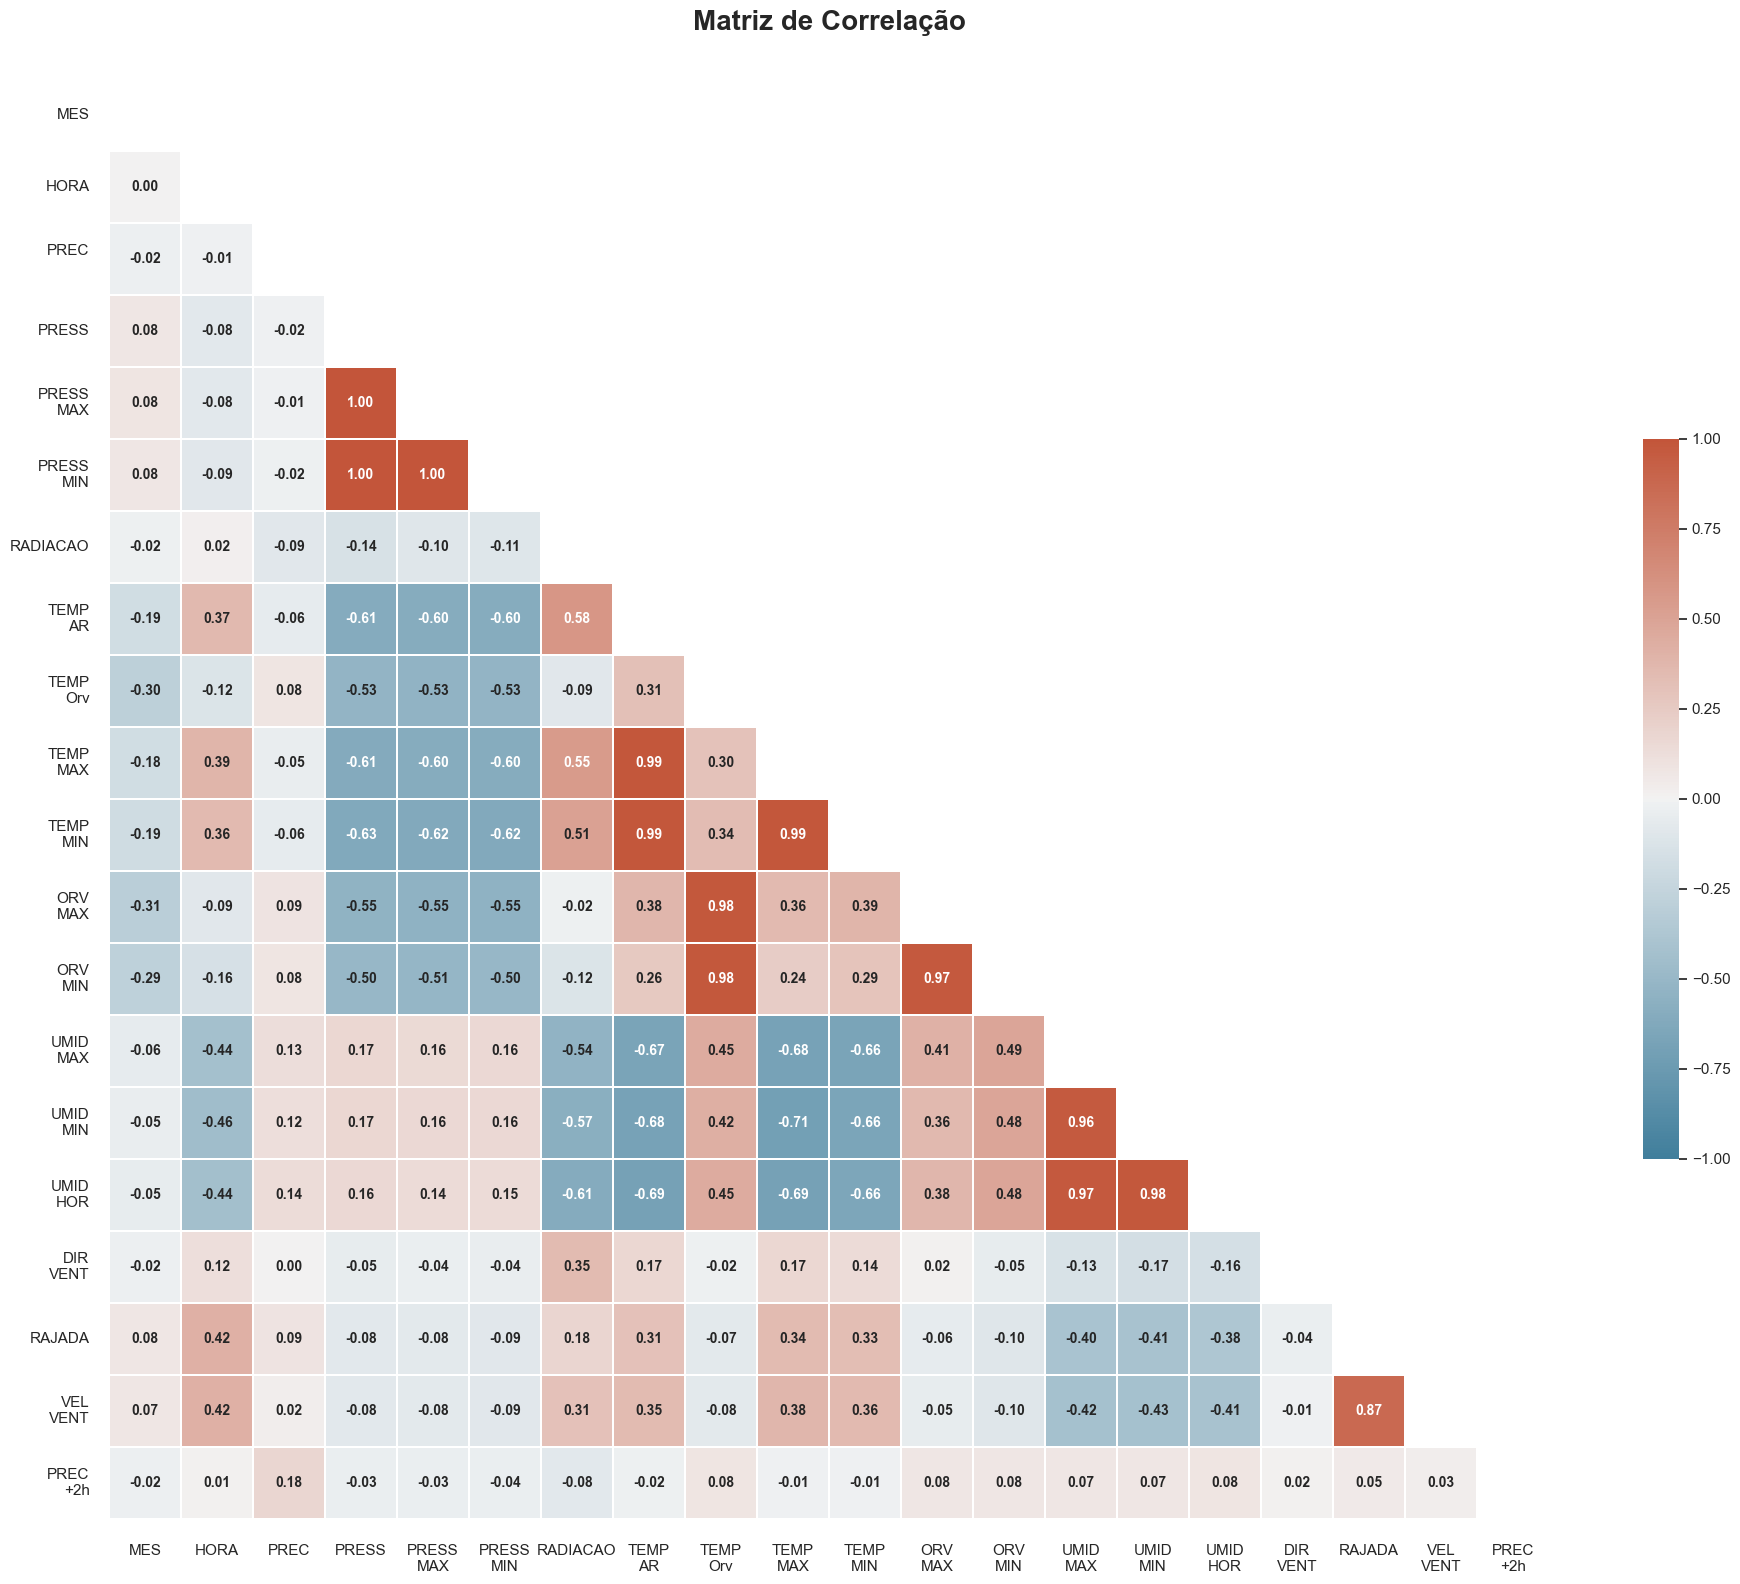

In [10]:
nomes_curtos = {
    'MES': 'MES',
    'HORA': 'HORA',

    'PRECIPITACAO_MM': 'PREC\n',
    'PRECIPITACAO_T2_MM': 'PREC\n+2h',

    'PRESSAO_ESTACAO_MB': 'PRESS',
    'PRESSAO_ESTACAO_MAX_H_ANT_MB': 'PRESS\nMAX',
    'PRESSAO_ESTACAO_MIN_H_ANT_MB': 'PRESS\nMIN',

    'RADIACAO_GLOBAL_KJ_M2': 'RADIACAO',

    'TEMP_AR_C': 'TEMP\nAR',
    'TEMP_ORVALHO_C': 'TEMP\nOrv',

    'TEMP_MAX_H_ANT_C': 'TEMP\nMAX',
    'TEMP_MIN_H_ANT_C': 'TEMP\nMIN',

    'TEMP_ORVALHO_MAX_H_ANT_C': 'ORV\nMAX',
    'TEMP_ORVALHO_MIN_H_ANT_C': 'ORV\nMIN',

    'UMIDADE_REL_MAX_H_ANT_PCT': 'UMID\nMAX',
    'UMIDADE_REL_MIN_H_ANT_PCT': 'UMID\nMIN',
    'UMIDADE_REL_HORARIA_PCT': 'UMID\nHOR',

    'VENTO_DIRECAO_GRAUS': 'DIR\nVENT',
    'VENTO_RAJADA_MAX_MS': 'RAJADA',
    'VENTO_VELOCIDADE_MS': 'VEL\nVENT',
}

# Seleciona apenas colunas originais (sem lag features)
colunas_originais = [
    c for c in df.columns
    if '_LAG_' not in c
]

df_correlacao = df[colunas_originais].copy()

# Garante que a variável alvo fique no final
if 'PRECIPITACAO_T2_MM' in df_correlacao.columns:

    cols = [
        c for c in df_correlacao.columns
        if c != 'PRECIPITACAO_T2_MM'
    ] + ['PRECIPITACAO_T2_MM']

    df_correlacao = df_correlacao[cols]

# Matriz de correlação
matriz_corr = (
    df_correlacao
    .rename(columns=nomes_curtos)
    .corr()
)

# Remove valores muito pequenos para evitar -0.00
matriz_corr[np.abs(matriz_corr) < 0.005] = 0.0
matriz_corr = matriz_corr + 0.0

# Configuração visual
sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(20, 16))

# Máscara para esconder triângulo superior
mask = np.triu(
    np.ones_like(matriz_corr, dtype=bool),
    k=0
)

# Paleta de cores
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Heatmap
sns.heatmap(
    matriz_corr,
    mask=mask,
    cmap=cmap,
    vmax=1,
    vmin=-1,
    center=0,
    square=True,
    linewidths=1.2,
    annot=True,
    fmt=".2f",
    cbar_kws={"shrink": 0.5},
    annot_kws={
        "size": 10,
        "weight": "bold"
    },
    ax=ax
)

# Ajustes dos eixos
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0,
    ha='center',
    va='top',
    fontsize=11
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    ha='right',
    va='center',
    fontsize=11
)

ax.tick_params(axis='x', pad=12)
ax.tick_params(axis='y', pad=8)

# Título
ax.set_title(
    'Matriz de Correlação',
    fontsize=20,
    pad=35,
    weight='bold'
)

plt.tight_layout()

plt.show()